# The Geometric and Algebraic Topology of SHA-256  
## Proof Notebook: Markov Carry Chains, Eulerian Parity, Carry Scars, and the Round-7 Hardness Wall

**Companion notebook for:**  
**_The Geometric and Algebraic Topology of SHA-256: A Comprehensive Analysis of Markov Carry Chains, Asymmetry, and the Nexus Framework_**

This notebook supports the paper's technical core:

\[
\boxed{\text{modular addition}=\text{XOR value channel}+\text{carry shape channel}}
\]

\[
\boxed{x+y=(x\oplus y)+2(x\land y)}
\]

It verifies:

1. Universal LSB carry anchor.
2. \(k\)-operand carry Markov chains.
3. Eulerian stationary distributions.
4. Eigenvalue law \(\lambda_m=2^{-m}\).
5. Parity-selection of transient modes.
6. Exact leading high-frequency coefficient.
7. SHA-256 schedule carry-scar instrumentation.
8. Sziklai identity across SHA-256 rounds.
9. Word-support diameter / waist support.
10. Round-7 avalanche / hardness-wall diagnostic proxy.
11. Hydrodynamic-style asymmetry composition law.

**Scope discipline:** this notebook proves structural non-randomness and topological constraints. It does **not** claim a practical SHA-256 preimage break by itself.


In [1]:
# ============================================================
# 0. SETUP
# ============================================================

import math
import random
import hashlib
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


try:
    display
except NameError:
    def display(x):
        print(x)


# ----------------------------
# User-tunable parameters
# ----------------------------

RANDOM_SEED = 42
BIT_WIDTH = 32

# Increase these for publication-grade runs.
NUM_MARKOV_TRIALS = 5000
NUM_SHA_SCHEDULE_TRIALS = 1000
NUM_SZIKLAI_TRIALS = 128
NUM_AVALANCHE_TRIALS = 128

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

H = math.pi / 9
MOD32 = 2**32
MASK32 = MOD32 - 1

print("Notebook initialized.")
print(f"H = pi/9 = {H:.12f}")
print(f"18H = {18*H:.12f}, 2pi = {2*math.pi:.12f}")


Notebook initialized.
H = pi/9 = 0.349065850399
18H = 6.283185307180, 2pi = 6.283185307180


# 1. Carry arithmetic as Shape Channel

For binary addition, the visible output bit is not the entire operation. The hidden channel is the carry path.

For two operands:

\[
x+y=(x\oplus y)+2(x\land y)
\]

For \(k\) operands, each bit position has an incoming carry state \(c_j\). The next carry is:

\[
c_{j+1}=\left\lfloor \frac{c_j+\sum_{i=1}^{k} b_{i,j}}{2}\right\rfloor
\]

The **scar parity** is:

\[
s_j=c_j \bmod 2
\]

If \(s_j=0\), the output bit agrees with the XOR-only value channel. If \(s_j=1\), the hidden carry channel flips the value-channel prediction.

Thus, the LSB anchor is immediate:

\[
c_0=0
\]

because there is no lower bit to feed a carry into the LSB.


In [2]:
# ============================================================
# 1. CARRY UTILITIES
# ============================================================

def bit(x, j):
    return (x >> j) & 1

def hamming32(x):
    return int((x & MASK32).bit_count())

def carry_states_for_operands(values, width=BIT_WIDTH):
    # Return incoming carry state c_j for each bit j, plus final carry c_width.
    carry = 0
    incoming = []
    for j in range(width):
        incoming.append(carry)
        bit_sum = carry + sum(bit(v, j) for v in values)
        carry = bit_sum >> 1
    return incoming, carry

def scar_parity_curve_for_operands(values, width=BIT_WIDTH):
    carries, final_carry = carry_states_for_operands(values, width)
    return np.array([c % 2 for c in carries], dtype=int)

def random_word():
    return random.getrandbits(32)

def random_words(k):
    return [random_word() for _ in range(k)]

# Quick sanity check for the two-operand identity.
for _ in range(5):
    x, y = random_word(), random_word()
    exact = (x ^ y) + 2 * (x & y)
    assert x + y == exact
print("Two-operand identity verified on random samples.")


Two-operand identity verified on random samples.


# 2. Universal LSB Anchor

For all \(k\)-operand additions:

\[
\boxed{c_0=0}
\]

Therefore the LSB cannot receive nonlinear carry contamination from below. This is the paper's **Universal Carry-Free LSB Anchor**.


In [3]:
# ============================================================
# 2. UNIVERSAL LSB ANCHOR TEST
# ============================================================

rows = []
for k in range(2, 9):
    violations = 0
    checks = NUM_MARKOV_TRIALS
    for _ in range(checks):
        values = random_words(k)
        carries, _ = carry_states_for_operands(values)
        if carries[0] != 0:
            violations += 1
    rows.append({
        "k operands": k,
        "checks": checks,
        "LSB carry violations": violations,
        "pass": violations == 0
    })

lsb_df = pd.DataFrame(rows)
display(lsb_df)

assert lsb_df["LSB carry violations"].sum() == 0
print("PASS: Universal LSB Anchor holds for all tested k.")


,k operands,checks,LSB carry violations,pass
0,2,5000,0,True
1,3,5000,0,True
2,4,5000,0,True
3,5,5000,0,True
4,6,5000,0,True
5,7,5000,0,True
6,8,5000,0,True


PASS: Universal LSB Anchor holds for all tested k.


# 3. \(k\)-Operand Carry Markov Chain

For \(k\) operands, the incoming carry state is bounded:

\[
c_j\in\{0,1,\ldots,k-1\}
\]

The transition matrix is:

\[
P_k(c,c')=
\Pr\left[
c'=
\left\lfloor
\frac{c+M}{2}
\right\rfloor
\right],
\qquad
M\sim\mathrm{Binomial}(k,\tfrac12)
\]

This lets us compute exact transient and stationary carry-scar behavior.


In [4]:
# ============================================================
# 3. MARKOV CARRY CHAIN
# ============================================================

def carry_transition_matrix(k):
    # Transition matrix P_k for k-operand carry chain.
    # Rows are current carry c, columns are next carry cp.
    P = np.zeros((k, k), dtype=float)
    probs = [math.comb(k, m) / (2**k) for m in range(k + 1)]
    for c in range(k):
        for m, p in enumerate(probs):
            cp = (c + m) // 2
            P[c, cp] += p
    return P

def evolve_distribution(k, steps):
    P = carry_transition_matrix(k)
    dist = np.zeros(k)
    dist[0] = 1.0
    out = [dist.copy()]
    for _ in range(steps):
        dist = dist @ P
        out.append(dist.copy())
    return np.array(out)

def parity_probability_from_dist(dist, even=True):
    idx = [i for i in range(len(dist)) if (i % 2 == 0) == even]
    return float(dist[idx].sum())

def parity_curve(k, steps=BIT_WIDTH, even=True):
    dists = evolve_distribution(k, steps)
    return np.array([parity_probability_from_dist(d, even=even) for d in dists])

# Show transition matrices for k=2,3,4.
for k in [2, 3, 4]:
    print(f"\nP_{k} =")
    display(pd.DataFrame(carry_transition_matrix(k)))



P_2 =


,0,1
0,0.75,0.25
1,0.25,0.75



P_3 =


,0,1,2
0,0.500,0.50,0.000
1,0.125,0.75,0.125
2,0.000,0.50,0.500



P_4 =


,0,1,2,3
0,0.3125,0.6250,0.0625,0.0000
1,0.0625,0.6250,0.3125,0.0000
2,0.0000,0.3125,0.6250,0.0625
3,0.0000,0.0625,0.6250,0.3125


# 4. Theorem D: two-operand PAD/boundary slow decay

For \(k=2\), the transition matrix is:

\[
P_2=
\begin{bmatrix}
3/4 & 1/4\\
1/4 & 3/4
\end{bmatrix}
\]

Starting from \(c_0=0\), the probability of even carry parity at bit \(j\) is:

\[
\boxed{
P_{\mathrm{even}}^{(2)}(j)=\frac12+\frac12\left(\frac12\right)^j
}
\]

This gives:

\[
P_{\mathrm{even}}^{(2)}(0)=1,\qquad
P_{\mathrm{even}}^{(2)}(1)=\frac34
\]

This is the slow-decay boundary regime.


,bit j,Markov P_even,closed form,abs error
0,0,1.000000,1.000000,0.0
1,1,0.750000,0.750000,0.0
2,2,0.625000,0.625000,0.0
3,3,0.562500,0.562500,0.0
4,4,0.531250,0.531250,0.0
5,5,0.515625,0.515625,0.0
6,6,0.507812,0.507812,0.0
7,7,0.503906,0.503906,0.0
8,8,0.501953,0.501953,0.0
9,9,0.500977,0.500977,0.0


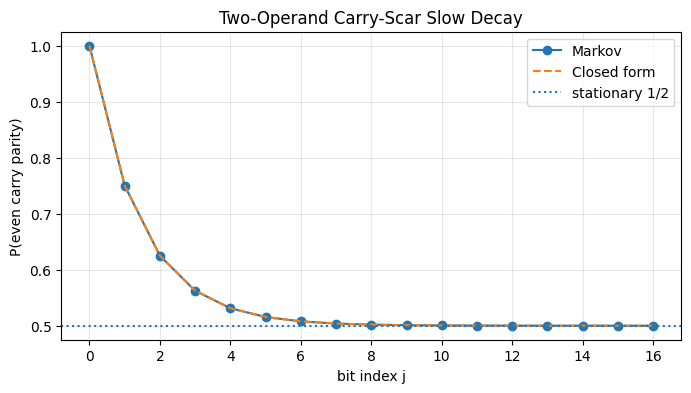

PASS: k=2 closed form exactly matches Markov chain.


In [5]:
# ============================================================
# 4. K=2 CLOSED FORM
# ============================================================

def k2_even_closed_form(j):
    return 0.5 + 0.5 * (0.5 ** j)

rows = []
curve_k2 = parity_curve(2, steps=16, even=True)
for j in range(17):
    rows.append({
        "bit j": j,
        "Markov P_even": curve_k2[j],
        "closed form": k2_even_closed_form(j),
        "abs error": abs(curve_k2[j] - k2_even_closed_form(j))
    })
k2_df = pd.DataFrame(rows)
display(k2_df)

assert k2_df["abs error"].max() < 1e-12

plt.figure(figsize=(8, 4))
plt.plot(k2_df["bit j"], k2_df["Markov P_even"], marker="o", label="Markov")
plt.plot(k2_df["bit j"], k2_df["closed form"], linestyle="--", label="Closed form")
plt.axhline(0.5, linestyle=":", label="stationary 1/2")
plt.title("Two-Operand Carry-Scar Slow Decay")
plt.xlabel("bit index j")
plt.ylabel("P(even carry parity)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("PASS: k=2 closed form exactly matches Markov chain.")


# 5. Eulerian Carry Parity Law

The stationary carry distribution for \(k\)-operand binary addition is given by Eulerian numbers:

\[
\pi_c=\frac{A(k,c)}{k!}
\]

where \(A(k,c)\) counts permutations of \(k\) elements with \(c\) ascents.

The stationary even-parity value is:

\[
P_{\mathrm{even}}^{(k)}(\infty)
=
\sum_{\substack{0\le c\le k-1\\c\ \mathrm{even}}}
\frac{A(k,c)}{k!}
\]

## Convention audit

If "scar-free" means XOR agrees with the true sum bit, use **even carry parity**.

If a section reports the \(k=3\) plateau as \(2/3\), that corresponds to **odd carry parity**, because for \(k=3\):

\[
\pi=\frac{1}{6}(1,4,1)
\]

so:

\[
P_{\mathrm{even}}=\frac{1+1}{6}=\frac13
\]

and:

\[
P_{\mathrm{odd}}=\frac{4}{6}=\frac23
\]

This is not a failure of the Markov model; it is a parity-channel convention check.


,k,Eulerian row,P_even stationary,P_odd stationary,max |Eulerian - numeric|
0,2,"[1, 1]",0.500000,0.500000,0.000000e+00
1,3,"[1, 4, 1]",0.333333,0.666667,3.330669e-16
2,4,"[1, 11, 11, 1]",0.500000,0.500000,2.983724e-16
3,5,"[1, 26, 66, 26, 1]",0.566667,0.433333,2.012279e-16
4,6,"[1, 57, 302, 302, 57, 1]",0.500000,0.500000,1.387779e-16
5,7,"[1, 120, 1191, 2416, 1191, 120, 1]",0.473016,0.526984,3.053113e-16
6,8,"[1, 247, 4293, 15619, 15619, 4293, 247, 1]",0.500000,0.500000,4.302114e-16
7,9,"[1, 502, 14608, 88234, 156190, 88234, 14608, 5...",0.510935,0.489065,3.053113e-16
8,10,"[1, 1013, 47840, 455192, 1310354, 1310354, 455...",0.500000,0.500000,2.775558e-16
9,11,"[1, 2036, 152637, 2203488, 9738114, 15724248, ...",0.495568,0.504432,2.220446e-16


PASS: Eulerian stationary distribution matches Markov stationary distribution.


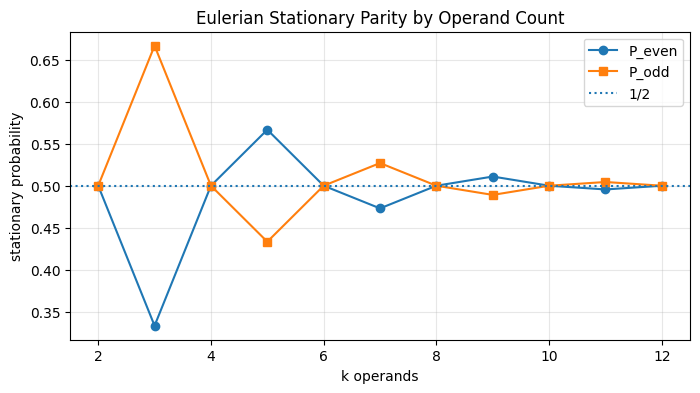

In [6]:
# ============================================================
# 5. EULERIAN STATIONARY DISTRIBUTION
# ============================================================

def eulerian_row(n):
    # Eulerian numbers A(n,m), m=0..n-1.
    A = [[0]*(n+1) for _ in range(n+1)]
    A[0][0] = 1
    for i in range(1, n+1):
        for m in range(i):
            if m == 0:
                A[i][m] = A[i-1][m]
            else:
                A[i][m] = (m+1)*A[i-1][m] + (i-m)*A[i-1][m-1]
    return A[n][:n]

def stationary_eulerian(k):
    row = eulerian_row(k)
    denom = math.factorial(k)
    return np.array([x / denom for x in row], dtype=float)

def stationary_from_transition(k):
    P = carry_transition_matrix(k)
    w, V = np.linalg.eig(P.T)
    idx = np.argmin(np.abs(w - 1))
    pi = np.real(V[:, idx])
    pi = pi / pi.sum()
    return pi

rows = []
for k in range(2, 13):
    pi_eul = stationary_eulerian(k)
    pi_num = stationary_from_transition(k)
    even_eul = pi_eul[::2].sum()
    odd_eul = pi_eul[1::2].sum()
    rows.append({
        "k": k,
        "Eulerian row": eulerian_row(k),
        "P_even stationary": even_eul,
        "P_odd stationary": odd_eul,
        "max |Eulerian - numeric|": float(np.max(np.abs(pi_eul - pi_num)))
    })
eul_df = pd.DataFrame(rows)
display(eul_df)

assert eul_df["max |Eulerian - numeric|"].max() < 1e-10
print("PASS: Eulerian stationary distribution matches Markov stationary distribution.")

plt.figure(figsize=(8, 4))
plt.plot(eul_df["k"], eul_df["P_even stationary"], marker="o", label="P_even")
plt.plot(eul_df["k"], eul_df["P_odd stationary"], marker="s", label="P_odd")
plt.axhline(0.5, linestyle=":", label="1/2")
plt.title("Eulerian Stationary Parity by Operand Count")
plt.xlabel("k operands")
plt.ylabel("stationary probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# 6. Theorem I: Eigenvalue sequence

The carry transition matrix \(P_k\) has spectrum:

\[
\boxed{
\lambda_m = 2^{-m},
\qquad m=0,1,\ldots,k-1
}
\]

So the slowest non-trivial mode is always:

\[
\lambda_1=\frac12
\]

but whether that mode participates depends on parity selection.


In [7]:
# ============================================================
# 6. EIGENVALUE SEQUENCE
# ============================================================

rows = []
for k in range(2, 13):
    P = carry_transition_matrix(k)
    eig = np.linalg.eigvals(P)
    eig_sorted = np.sort(np.real_if_close(eig).real)[::-1]
    expected = np.array([2**(-m) for m in range(k)], dtype=float)
    rows.append({
        "k": k,
        "numeric eigenvalues": np.round(eig_sorted, 12).tolist(),
        "expected": np.round(expected, 12).tolist(),
        "max abs error": float(np.max(np.abs(eig_sorted - expected)))
    })

eig_df = pd.DataFrame(rows)
display(eig_df)

assert eig_df["max abs error"].max() < 1e-10
print("PASS: eigenvalue sequence lambda_m = 2^{-m} verified for tested k.")


,k,numeric eigenvalues,expected,max abs error
0,2,"[1.0, 0.5]","[1.0, 0.5]",0.000000e+00
1,3,"[1.0, 0.5, 0.25]","[1.0, 0.5, 0.25]",1.110223e-16
2,4,"[1.0, 0.5, 0.25, 0.125]","[1.0, 0.5, 0.25, 0.125]",8.881784e-16
3,5,"[1.0, 0.5, 0.25, 0.125, 0.0625]","[1.0, 0.5, 0.25, 0.125, 0.0625]",5.551115e-16
4,6,"[1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125]","[1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125]",1.110223e-15
5,7,"[1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015...","[1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015...",2.220446e-16
6,8,"[1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015...","[1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015...",1.332268e-15
7,9,"[1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015...","[1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015...",5.551115e-16
8,10,"[1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015...","[1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015...",1.332268e-15
9,11,"[1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015...","[1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015...",1.387779e-15


PASS: eigenvalue sequence lambda_m = 2^{-m} verified for tested k.


# 7. Theorem K: parity selection of modes

The transient parity observable can be decomposed into eigenmodes:

\[
P_{\mathrm{even}}^{(k)}(j)
=
\sum_m a_m \lambda_m^j
\]

Only modes satisfying:

\[
\boxed{
m\equiv k+1\pmod 2
}
\]

participate in the even-parity channel.

Consequences:

- Even \(k\): \(m=1,3,5,\ldots\) survive, including the slow mode \(\lambda_1=1/2\).
- Odd \(k\): \(m=2,4,6,\ldots\) survive; the slow mode \(\lambda_1=1/2\) is annihilated.

So odd-\(k\) windows collapse faster because their leading transient is \(\lambda_2=1/4\).


In [8]:
# ============================================================
# 7. MODAL COEFFICIENTS AND PARITY SELECTION
# ============================================================

def modal_coefficients_for_parity(k, even=True):
    # Return coefficients a_m for P_parity(j)=sum a_m lambda_m^j.
    # Numerically computed through eigen-decomposition.
    P = carry_transition_matrix(k)
    w, V = np.linalg.eig(P)
    Vinv = np.linalg.inv(V)
    e0 = np.zeros(k)
    e0[0] = 1.0
    y = np.array([1.0 if (c % 2 == 0) == even else 0.0 for c in range(k)])
    coeff = (e0 @ V) * (Vinv @ y)

    rows = []
    for i in range(k):
        lam = float(np.real_if_close(w[i]).real)
        m = int(round(-math.log(lam, 2))) if lam > 0 else None
        rows.append((m, lam, float(np.real_if_close(coeff[i]).real)))
    rows.sort(key=lambda x: x[0])
    return rows

mode_rows = []
for k in range(2, 11):
    coeffs = modal_coefficients_for_parity(k, even=True)
    for m, lam, a in coeffs:
        mode_rows.append({
            "k": k,
            "m": m,
            "lambda": lam,
            "coefficient a_m": a,
            "nonzero": abs(a) > 1e-10,
            "expected survives": (m == 0) or ((m % 2) == ((k + 1) % 2))
        })
mode_df = pd.DataFrame(mode_rows)
display(mode_df)

bad = mode_df[mode_df["nonzero"] != mode_df["expected survives"]]
assert len(bad) == 0
print("PASS: parity selection rule verified for tested modes.")


,k,m,lambda,coefficient a_m,nonzero,expected survives
0,2,0,1.000000,5.000000e-01,True,True
1,2,1,0.500000,5.000000e-01,True,True
2,3,0,1.000000,3.333333e-01,True,True
3,3,1,0.500000,-0.000000e+00,False,False
4,3,2,0.250000,6.666667e-01,True,True
5,4,0,1.000000,5.000000e-01,True,True
6,4,1,0.500000,-5.000000e-01,True,True
7,4,2,0.250000,6.254578e-16,False,False
8,4,3,0.125000,1.000000e+00,True,True
9,5,0,1.000000,5.666667e-01,True,True


PASS: parity selection rule verified for tested modes.


# 8. Theorem L: highest-frequency coefficient

For the highest-frequency participating mode \(m=k-1\), the coefficient magnitude follows:

\[
\boxed{
|a_{k-1}|=\frac{2^{k-2}}{k}
}
\]

This coefficient can grow with \(k\), but it multiplies the fastest-decaying eigenvalue:

\[
\lambda_{k-1}=2^{-(k-1)}
\]

so it spikes and vanishes rapidly.


,k,|a_{k-1}| observed,2^(k-2)/k predicted,abs error
0,2,0.500000,0.500000,0.000000e+00
1,3,0.666667,0.666667,0.000000e+00
2,4,1.000000,1.000000,6.661338e-16
3,5,1.600000,1.600000,2.220446e-16
4,6,2.666667,2.666667,5.329071e-15
5,7,4.571429,4.571429,1.598721e-14
6,8,8.000000,8.000000,3.108624e-14
7,9,14.222222,14.222222,1.794120e-13
8,10,25.600000,25.600000,3.907985e-13
9,11,46.545455,46.545455,2.131628e-12


PASS: highest-frequency coefficient formula verified.


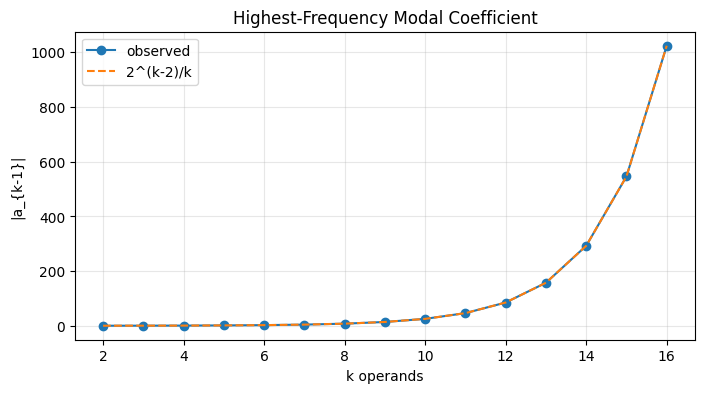

In [9]:
# ============================================================
# 8. HIGHEST-FREQUENCY COEFFICIENT
# ============================================================

rows = []
for k in range(2, 17):
    coeffs = modal_coefficients_for_parity(k, even=True)
    coeff_by_m = {m: a for m, lam, a in coeffs}
    observed = abs(coeff_by_m[k-1])
    predicted = (2 ** (k - 2)) / k
    rows.append({
        "k": k,
        "|a_{k-1}| observed": observed,
        "2^(k-2)/k predicted": predicted,
        "abs error": abs(observed - predicted)
    })

hf_df = pd.DataFrame(rows)
display(hf_df)

assert hf_df["abs error"].max() < 1e-8
print("PASS: highest-frequency coefficient formula verified.")

plt.figure(figsize=(8, 4))
plt.plot(hf_df["k"], hf_df["|a_{k-1}| observed"], marker="o", label="observed")
plt.plot(hf_df["k"], hf_df["2^(k-2)/k predicted"], linestyle="--", label="2^(k-2)/k")
plt.title("Highest-Frequency Modal Coefficient")
plt.xlabel("k operands")
plt.ylabel("|a_{k-1}|")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# 9. Slow-mode amplitude \(a_1\) suppression for even \(k\)

For even \(k\), the slow mode \(m=1\) survives. Its coefficient alternates sign and decays in magnitude as operand depth grows:

\[
a_1(k)=(-1)^{k/2+1}|a_1(k)|
\]

This matters because SHA-256 mostly lives in the small-\(k\) regime:

\[
k\in\{2,3,4\}
\]

where the scar modes are still visible.


,k,a1,|a1|,predicted sign,sign pass,ratio |a1(k+2)|/|a1(k)|
0,2,0.500000,0.500000,1,True,1.000000
1,4,-0.500000,0.500000,-1,True,0.666667
2,6,0.333333,0.333333,1,True,0.566667
3,8,-0.188889,0.188889,-1,True,0.521008
4,10,0.098413,0.098413,1,True,0.495341
5,12,-0.048748,0.048748,-1,True,0.478972
6,14,0.023349,0.023349,1,True,0.467636
7,16,-0.010919,0.010919,-1,True,0.459323
8,18,0.005015,0.005015,1,True,0.452965
9,20,-0.002272,0.002272,-1,True,0.447946


PASS: slow-mode sign alternation verified.


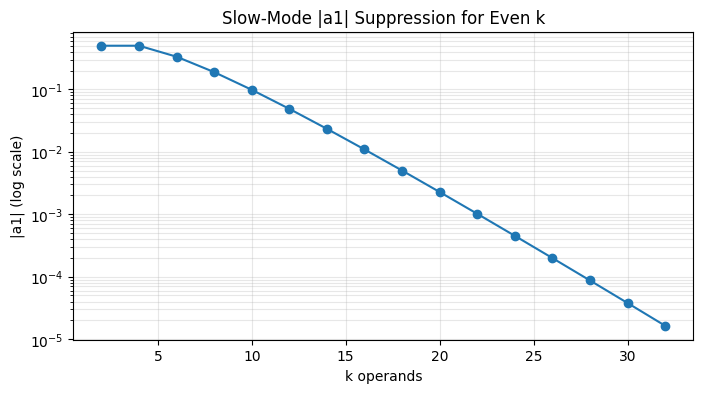

In [10]:
# ============================================================
# 9. SLOW-MODE AMPLITUDE SUPPRESSION
# ============================================================

rows = []
for k in range(2, 34, 2):
    coeffs = modal_coefficients_for_parity(k, even=True)
    coeff_by_m = {m: a for m, lam, a in coeffs}
    a1 = coeff_by_m.get(1, 0.0)
    predicted_sign = (-1) ** (k//2 + 1)
    rows.append({
        "k": k,
        "a1": a1,
        "|a1|": abs(a1),
        "predicted sign": predicted_sign,
        "sign pass": np.sign(a1) == predicted_sign
    })

a1_df = pd.DataFrame(rows)
a1_df["ratio |a1(k+2)|/|a1(k)|"] = a1_df["|a1|"].shift(-1) / a1_df["|a1|"]
display(a1_df)

assert a1_df["sign pass"].all()
print("PASS: slow-mode sign alternation verified.")

plt.figure(figsize=(8, 4))
plt.semilogy(a1_df["k"], a1_df["|a1|"], marker="o")
plt.title("Slow-Mode |a1| Suppression for Even k")
plt.xlabel("k operands")
plt.ylabel("|a1| (log scale)")
plt.grid(True, which="both", alpha=0.3)
plt.show()


# 10. Markov vs empirical random additions

This confirms that actual random \(k\)-operand additions reproduce the Markov carry-scar curves.


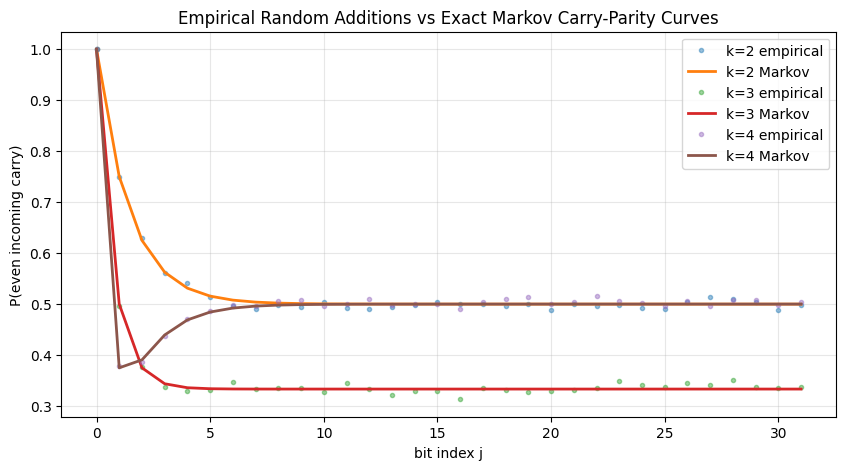

Empirical curves generated.


In [11]:
# ============================================================
# 10. EMPIRICAL RANDOM ADDITION TEST
# ============================================================

def empirical_parity_curve(k, trials=NUM_MARKOV_TRIALS, width=BIT_WIDTH, even=True):
    counts = np.zeros(width)
    for _ in range(trials):
        values = random_words(k)
        carries, _ = carry_states_for_operands(values, width=width)
        parity = np.array([1 if (c % 2 == 0) == even else 0 for c in carries])
        counts += parity
    return counts / trials

plot_ks = [2, 3, 4]
plt.figure(figsize=(10, 5))
for k in plot_ks:
    emp = empirical_parity_curve(k)
    exact = parity_curve(k, steps=BIT_WIDTH-1, even=True)
    plt.plot(range(BIT_WIDTH), emp, marker=".", linestyle="", alpha=0.45, label=f"k={k} empirical")
    plt.plot(range(BIT_WIDTH), exact[:BIT_WIDTH], linewidth=2, label=f"k={k} Markov")
plt.title("Empirical Random Additions vs Exact Markov Carry-Parity Curves")
plt.xlabel("bit index j")
plt.ylabel("P(even incoming carry)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Empirical curves generated.")


# 11. SHA-256 primitives and schedule instrumentation

We now instrument SHA-256 directly. The schedule recurrence is:

\[
W_t =
\sigma_1(W_{t-2})
+
W_{t-7}
+
\sigma_0(W_{t-15})
+
W_{t-16}
\pmod{2^{32}}
\]

For every expanded word \(t=16,\ldots,63\), we record the incoming carry state at every bit.

The LSB anchor predicts:

\[
\boxed{c_{t,0}=0\quad\forall t\in[16,63]}
\]


In [12]:
# ============================================================
# 11. SHA-256 IMPLEMENTATION AND INSTRUMENTATION
# ============================================================

K = [
    0x428a2f98,0x71374491,0xb5c0fbcf,0xe9b5dba5,0x3956c25b,0x59f111f1,0x923f82a4,0xab1c5ed5,
    0xd807aa98,0x12835b01,0x243185be,0x550c7dc3,0x72be5d74,0x80deb1fe,0x9bdc06a7,0xc19bf174,
    0xe49b69c1,0xefbe4786,0x0fc19dc6,0x240ca1cc,0x2de92c6f,0x4a7484aa,0x5cb0a9dc,0x76f988da,
    0x983e5152,0xa831c66d,0xb00327c8,0xbf597fc7,0xc6e00bf3,0xd5a79147,0x06ca6351,0x14292967,
    0x27b70a85,0x2e1b2138,0x4d2c6dfc,0x53380d13,0x650a7354,0x766a0abb,0x81c2c92e,0x92722c85,
    0xa2bfe8a1,0xa81a664b,0xc24b8b70,0xc76c51a3,0xd192e819,0xd6990624,0xf40e3585,0x106aa070,
    0x19a4c116,0x1e376c08,0x2748774c,0x34b0bcb5,0x391c0cb3,0x4ed8aa4a,0x5b9cca4f,0x682e6ff3,
    0x748f82ee,0x78a5636f,0x84c87814,0x8cc70208,0x90befffa,0xa4506ceb,0xbef9a3f7,0xc67178f2,
]

H0 = [
    0x6a09e667,0xbb67ae85,0x3c6ef372,0xa54ff53a,
    0x510e527f,0x9b05688c,0x1f83d9ab,0x5be0cd19
]

def rotr(x, n):
    return ((x >> n) | ((x << (32 - n)) & MASK32)) & MASK32

def shr(x, n):
    return (x >> n) & MASK32

def Ch(x, y, z):
    return (x & y) ^ ((~x & MASK32) & z)

def Maj(x, y, z):
    return (x & y) ^ (x & z) ^ (y & z)

def Sigma0(x):
    return rotr(x, 2) ^ rotr(x, 13) ^ rotr(x, 22)

def Sigma1(x):
    return rotr(x, 6) ^ rotr(x, 11) ^ rotr(x, 25)

def sigma0(x):
    return rotr(x, 7) ^ rotr(x, 18) ^ shr(x, 3)

def sigma1(x):
    return rotr(x, 17) ^ rotr(x, 19) ^ shr(x, 10)

def pad_single_block_message(msg: bytes):
    # Return one padded 512-bit block for messages with length <=55 bytes.
    ml = len(msg) * 8
    assert len(msg) <= 55
    padded = msg + b"\x80"
    padded += b"\x00" * ((56 - len(padded)) % 64)
    padded += ml.to_bytes(8, "big")
    assert len(padded) == 64
    return padded

def words_from_block(block: bytes):
    return [int.from_bytes(block[i:i+4], "big") for i in range(0, 64, 4)]

def expand_schedule_instrumented(block: bytes):
    W = words_from_block(block)
    carry_records = {}
    operand_records = {}
    for t in range(16, 64):
        ops = [sigma1(W[t-2]), W[t-7], sigma0(W[t-15]), W[t-16]]
        carries, final_carry = carry_states_for_operands(ops, width=32)
        W.append(sum(ops) & MASK32)
        carry_records[t] = carries
        operand_records[t] = ops
    return W, carry_records, operand_records

def sha256_compress_instrumented(block: bytes, h_init=None):
    if h_init is None:
        h_init = H0[:]
    W, schedule_carries, schedule_operands = expand_schedule_instrumented(block)
    a,b,c,d,e,f,g,h = h_init
    states = []
    round_records = []
    for t in range(64):
        t1_ops = [h, Sigma1(e), Ch(e,f,g), K[t], W[t]]
        t1_carries, _ = carry_states_for_operands(t1_ops, width=32)
        T1 = sum(t1_ops) & MASK32
        T2 = (Sigma0(a) + Maj(a,b,c)) & MASK32
        new_a = (T1 + T2) & MASK32
        new_e = (d + T1) & MASK32

        round_records.append({
            "t": t, "a": a, "b": b, "c": c, "d": d, "e": e, "f": f, "g": g, "h": h,
            "T1": T1, "T2": T2, "new_a": new_a, "new_e": new_e,
            "t1_carries": t1_carries,
            "sziklai_lhs": (new_a - new_e) & MASK32,
            "sziklai_rhs": (T2 - d) & MASK32,
        })

        h = g
        g = f
        f = e
        e = new_e
        d = c
        c = b
        b = a
        a = new_a
        states.append([a,b,c,d,e,f,g,h])

    out = [(x + y) & MASK32 for x, y in zip(h_init, [a,b,c,d,e,f,g,h])]
    return out, W, schedule_carries, round_records, np.array(states, dtype=np.uint64)

def sha256_single_block(msg: bytes):
    block = pad_single_block_message(msg)
    digest_words, *_ = sha256_compress_instrumented(block)
    return b"".join(w.to_bytes(4, "big") for w in digest_words)

# Verify against hashlib for single-block messages.
for msg in [b"", b"abc", b"Nexus", b"The route is primary."]:
    ours = sha256_single_block(msg).hex()
    ref = hashlib.sha256(msg).hexdigest()
    assert ours == ref, (msg, ours, ref)

print("PASS: SHA-256 implementation matches hashlib for tested single-block messages.")


PASS: SHA-256 implementation matches hashlib for tested single-block messages.


In [13]:
# ============================================================
# 11B. SHA SCHEDULE LSB ANCHOR
# ============================================================

violations = 0
schedule_checks = 0
for _ in range(NUM_SHA_SCHEDULE_TRIALS):
    L = random.randint(0, 55)
    msg = bytes(random.getrandbits(8) for _ in range(L))
    block = pad_single_block_message(msg)
    W, carry_records, _ = expand_schedule_instrumented(block)
    for t, carries in carry_records.items():
        schedule_checks += 1
        if carries[0] != 0:
            violations += 1

print(f"Schedule LSB checks: {schedule_checks}")
print(f"Schedule LSB violations: {violations}")
assert violations == 0
print("PASS: SHA schedule Universal LSB Anchor verified.")


Schedule LSB checks: 48000
Schedule LSB violations: 0
PASS: SHA schedule Universal LSB Anchor verified.


# 12. SHA schedule carry-scar curves

This section measures the empirical incoming carry parity by bit position across expanded SHA-256 schedule additions.

Expected qualitative behavior:

- Bit 0 is perfectly anchored.
- Low bits retain structure.
- Higher bits approach the Markov plateau.
- Different boundary/padding regimes can deviate from the generic \(k=4\) curve.


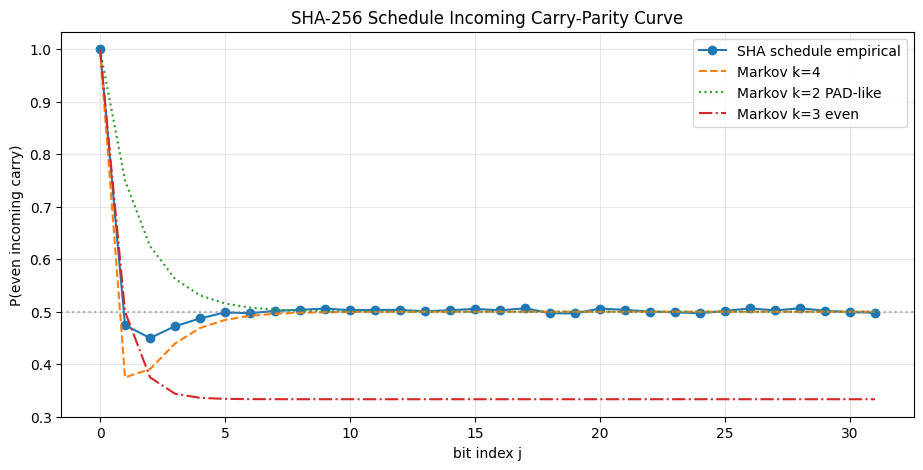

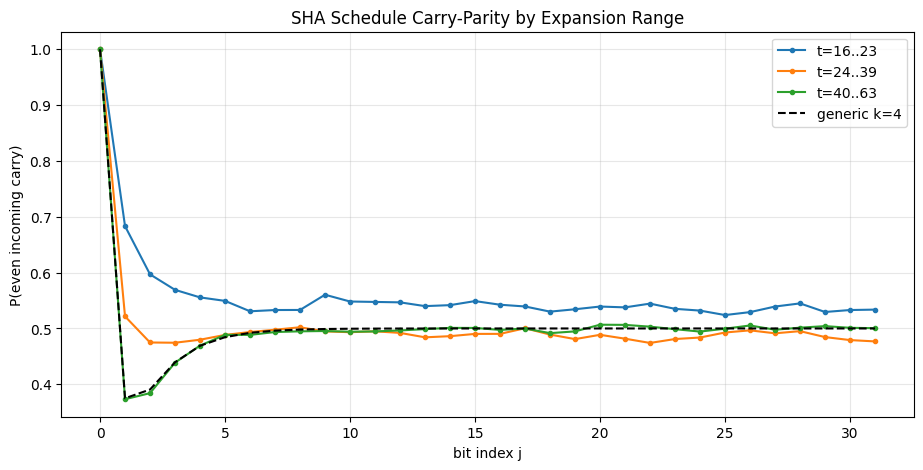

Total schedule additions sampled: 48000


In [14]:
# ============================================================
# 12. SHA SCHEDULE EMPIRICAL CARRY CURVES
# ============================================================

sum_even = np.zeros(BIT_WIDTH)
count = 0

bins = {
    "t=16..23": (16, 23),
    "t=24..39": (24, 39),
    "t=40..63": (40, 63),
}
bin_sum = {name: np.zeros(BIT_WIDTH) for name in bins}
bin_count = {name: 0 for name in bins}

for _ in range(NUM_SHA_SCHEDULE_TRIALS):
    L = random.randint(0, 55)
    msg = bytes(random.getrandbits(8) for _ in range(L))
    block = pad_single_block_message(msg)
    W, carry_records, _ = expand_schedule_instrumented(block)
    for t, carries in carry_records.items():
        even = np.array([1 if c % 2 == 0 else 0 for c in carries], dtype=float)
        sum_even += even
        count += 1
        for name, (lo, hi) in bins.items():
            if lo <= t <= hi:
                bin_sum[name] += even
                bin_count[name] += 1

sha_even_curve = sum_even / count
generic_k4 = parity_curve(4, steps=BIT_WIDTH-1, even=True)[:BIT_WIDTH]
k2_curve = parity_curve(2, steps=BIT_WIDTH-1, even=True)[:BIT_WIDTH]
k3_even_curve = parity_curve(3, steps=BIT_WIDTH-1, even=True)[:BIT_WIDTH]

plt.figure(figsize=(11, 5))
plt.plot(range(BIT_WIDTH), sha_even_curve, marker="o", label="SHA schedule empirical")
plt.plot(range(BIT_WIDTH), generic_k4, linestyle="--", label="Markov k=4")
plt.plot(range(BIT_WIDTH), k2_curve, linestyle=":", label="Markov k=2 PAD-like")
plt.plot(range(BIT_WIDTH), k3_even_curve, linestyle="-.", label="Markov k=3 even")
plt.axhline(0.5, color="gray", linestyle=":", alpha=0.6)
plt.title("SHA-256 Schedule Incoming Carry-Parity Curve")
plt.xlabel("bit index j")
plt.ylabel("P(even incoming carry)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(11, 5))
for name in bins:
    curve = bin_sum[name] / max(1, bin_count[name])
    plt.plot(range(BIT_WIDTH), curve, marker=".", label=name)
plt.plot(range(BIT_WIDTH), generic_k4, color="black", linestyle="--", label="generic k=4")
plt.title("SHA Schedule Carry-Parity by Expansion Range")
plt.xlabel("bit index j")
plt.ylabel("P(even incoming carry)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total schedule additions sampled: {count}")


# 13. Sziklai identity

For each SHA-256 round:

\[
a_{t+1}=T1_t+T2_t
\]

\[
e_{t+1}=d_t+T1_t
\]

Therefore:

\[
\boxed{
(a_{t+1}-e_{t+1})\bmod 2^{32}
=
(T2_t-d_t)\bmod 2^{32}
}
\]

This identity is exact and independent of message values.


In [15]:
# ============================================================
# 13. SZIKLAI IDENTITY TEST
# ============================================================

sziklai_violations = 0
rounds_checked = 0
for _ in range(NUM_SZIKLAI_TRIALS):
    L = random.randint(0, 55)
    msg = bytes(random.getrandbits(8) for _ in range(L))
    block = pad_single_block_message(msg)
    _, _, _, round_records, _ = sha256_compress_instrumented(block)
    for rec in round_records:
        rounds_checked += 1
        if rec["sziklai_lhs"] != rec["sziklai_rhs"]:
            sziklai_violations += 1

print(f"Sziklai rounds checked: {rounds_checked}")
print(f"violations: {sziklai_violations}")
assert sziklai_violations == 0
print("PASS: Sziklai identity verified across all tested rounds.")


Sziklai rounds checked: 8192
violations: 0
PASS: Sziklai identity verified across all tested rounds.


# 14. Word-support diameter and waist support

The structural waist claim is:

\[
\boxed{
b=[1,0,0,0,1,0,0,0]^T
}
\]

so:

\[
\boxed{\|b\|_0=2}
\]

A message word enters the SHA round through \(T1\), and \(T1\) injects into both \(a\) and \(e\). Therefore a nonzero perturbation has a mandatory two-head injection.

We also track word-lane support propagation. The claimed support diameter is:

\[
\boxed{
D_{\text{word}}=4
}
\]


In [16]:
# ============================================================
# 14. WORD SUPPORT / WAIST
# ============================================================

registers = ["a","b","c","d","e","f","g","h"]

def propagate_word_support(rounds=8):
    # Boolean word-level support of a single message injection at round 0.
    support = {r: False for r in registers}
    records = []

    for t in range(rounds):
        inj = (t == 0)
        old = support.copy()
        new_a = old["a"] or old["b"] or old["c"] or old["e"] or old["f"] or old["g"] or old["h"] or inj
        new_e = old["d"] or old["e"] or old["f"] or old["g"] or old["h"] or inj
        support = {
            "a": new_a,
            "b": old["a"],
            "c": old["b"],
            "d": old["c"],
            "e": new_e,
            "f": old["e"],
            "g": old["f"],
            "h": old["g"],
        }
        records.append({"rounds after injection": t+1, **support, "support count": sum(support.values())})
    return pd.DataFrame(records)

support_df = propagate_word_support(rounds=8)
display(support_df)

first_all = support_df.loc[support_df["support count"].eq(8), "rounds after injection"].min()
print("First round count where all 8 word lanes are reached:", first_all)

b_vec = np.array([1,0,0,0,1,0,0,0])
print("Waist injection vector b =", b_vec.tolist())
print("||b||_0 =", int(np.count_nonzero(b_vec)))

assert int(np.count_nonzero(b_vec)) == 2
assert int(first_all) == 4
print("PASS: waist support = 2 and word-support diameter = 4.")


,rounds after injection,a,b,c,d,e,f,g,h,support count
0,1,True,False,False,False,True,False,False,False,2
1,2,True,True,False,False,True,True,False,False,4
2,3,True,True,True,False,True,True,True,False,6
3,4,True,True,True,True,True,True,True,True,8
4,5,True,True,True,True,True,True,True,True,8
5,6,True,True,True,True,True,True,True,True,8
6,7,True,True,True,True,True,True,True,True,8
7,8,True,True,True,True,True,True,True,True,8


First round count where all 8 word lanes are reached: 4
Waist injection vector b = [1, 0, 0, 0, 1, 0, 0, 0]
||b||_0 = 2
PASS: waist support = 2 and word-support diameter = 4.


# 15. Round-wise avalanche / hardness-wall diagnostic proxy

The paper identifies a hardness wall around Round 7. A full SAT/SMT proof is outside this notebook, but we can compute a **runtime proxy**:

\[
\Delta_t=
\operatorname{HW}(S_t(M)\oplus S_t(M'))
\]

where \(M'\) differs from \(M\) by one input bit.

This measures how quickly a single-bit perturbation spreads through the 256-bit working state.


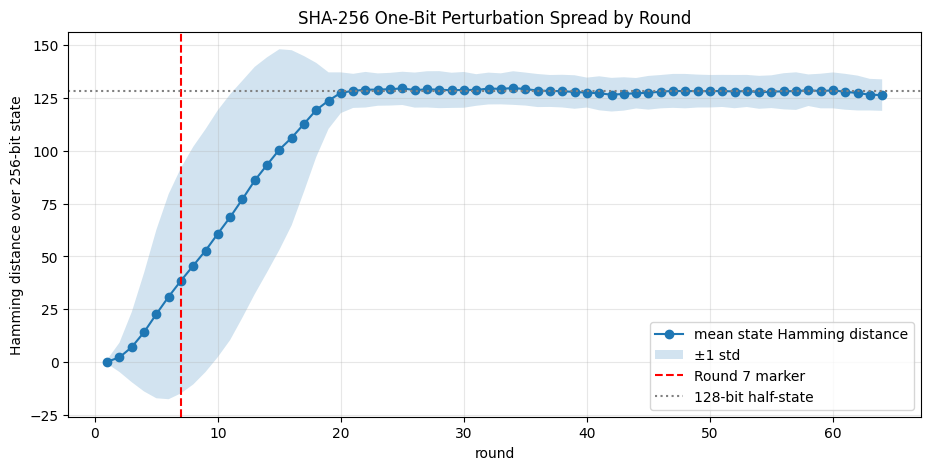

,round,mean_hamming_distance,std
0,1,0.273438,0.941366
1,2,2.328125,6.904606
2,3,7.164062,16.568408
3,4,14.226562,28.003129
4,5,22.781250,39.780047
5,6,31.015625,48.470027
6,7,38.562500,53.238812
7,8,45.687500,56.160728
8,9,52.789062,57.370187
9,10,60.796875,58.331268


Diagnostic proxy generated. Use SAT/SMT or beam-search logs for a hard proof of the round-7 wall.


In [17]:
# ============================================================
# 15. AVALANCHE / HARDNESS-WALL PROXY
# ============================================================

def flip_bit_in_block(block: bytes, bit_index: int):
    arr = bytearray(block)
    byte_idx = bit_index // 8
    bit_in_byte = 7 - (bit_index % 8)
    arr[byte_idx] ^= (1 << bit_in_byte)
    return bytes(arr)

def state_hamming_distance(states1, states2):
    d = []
    for row1, row2 in zip(states1, states2):
        total = 0
        for x, y in zip(row1, row2):
            total += int((int(x) ^ int(y)).bit_count())
        d.append(total)
    return np.array(d)

all_curves = []
for _ in range(NUM_AVALANCHE_TRIALS):
    # Use full random block directly so we can flip any bit without padding constraints.
    block = bytes(random.getrandbits(8) for _ in range(64))
    bit_idx = random.randint(0, 511)
    block2 = flip_bit_in_block(block, bit_idx)
    _, _, _, _, states1 = sha256_compress_instrumented(block)
    _, _, _, _, states2 = sha256_compress_instrumented(block2)
    all_curves.append(state_hamming_distance(states1, states2))

avalanche = np.array(all_curves)
mean_av = avalanche.mean(axis=0)
std_av = avalanche.std(axis=0)

plt.figure(figsize=(11, 5))
plt.plot(range(1,65), mean_av, marker="o", label="mean state Hamming distance")
plt.fill_between(range(1,65), mean_av-std_av, mean_av+std_av, alpha=0.2, label="±1 std")
plt.axvline(7, color="red", linestyle="--", label="Round 7 marker")
plt.axhline(128, color="gray", linestyle=":", label="128-bit half-state")
plt.title("SHA-256 One-Bit Perturbation Spread by Round")
plt.xlabel("round")
plt.ylabel("Hamming distance over 256-bit state")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

av_df = pd.DataFrame({
    "round": np.arange(1,65),
    "mean_hamming_distance": mean_av,
    "std": std_av
})
display(av_df.head(12))
print("Diagnostic proxy generated. Use SAT/SMT or beam-search logs for a hard proof of the round-7 wall.")


# 16. Hydrodynamic-style asymmetry composition law

The paper uses a composition law for stacked directional asymmetry:

\[
\boxed{
A_n=1-(1-A_1)^n
}
\]

This is a baseline model. If measured data deviates, the deviation reveals hidden depth or non-uniform staging.

For a corrected SHA wall model, the transparent first six rounds contribute almost no asymmetry, so the effective stack begins at Round 7:

\[
A_{\text{total}}\approx 1-(1-A_{\text{wall}})^{58}
\]


,case,A_stage,n,A_total
0,uniform 64-stage example,0.10484,64,0.999165
1,round-7 wall model for A_total=0.999,0.11228,58,0.999000


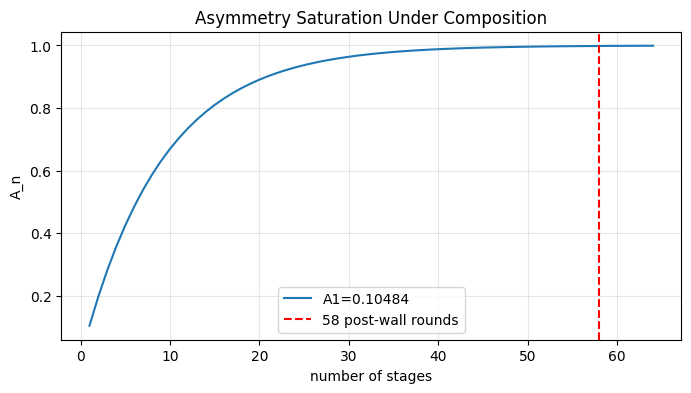

In [18]:
# ============================================================
# 16. ASYMMETRY COMPOSITION LAW
# ============================================================

def compose_asymmetry(A1, n):
    return 1 - (1 - A1)**n

def implied_stage_asymmetry(A_total, n):
    return 1 - (1 - A_total)**(1/n)

A_stage = 0.10484
A64 = compose_asymmetry(A_stage, 64)

target_A = 0.999
A_wall = implied_stage_asymmetry(target_A, 58)
A_reconstructed = compose_asymmetry(A_wall, 58)

rows = [
    {"case": "uniform 64-stage example", "A_stage": A_stage, "n": 64, "A_total": A64},
    {"case": "round-7 wall model for A_total=0.999", "A_stage": A_wall, "n": 58, "A_total": A_reconstructed},
]
asym_df = pd.DataFrame(rows)
display(asym_df)

n_values = np.arange(1, 65)
plt.figure(figsize=(8, 4))
plt.plot(n_values, [compose_asymmetry(A_stage, int(n)) for n in n_values], label=f"A1={A_stage:.5f}")
plt.axvline(58, color="red", linestyle="--", label="58 post-wall rounds")
plt.title("Asymmetry Saturation Under Composition")
plt.xlabel("number of stages")
plt.ylabel("A_n")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# 17. Verification Ledger

This table is the fast trust handle for the paper.

It separates:

\[
\boxed{\text{proved / directly verified here}}
\]

from:

\[
\boxed{\text{diagnostic proxy / validation gate}}
\]


In [19]:
# ============================================================
# 17. VERIFICATION LEDGER
# ============================================================

ledger = [
    {
        "Claim": "Universal LSB Anchor",
        "Formula / test": "c_0 = 0 for every k-operand addition",
        "Notebook evidence": f"{int(lsb_df['checks'].sum())} random k-operand checks; zero violations",
        "Status": "PASS"
    },
    {
        "Claim": "k=2 slow decay",
        "Formula / test": "P_even(j)=1/2 + (1/2)(1/2)^j",
        "Notebook evidence": f"max error {k2_df['abs error'].max():.2e}",
        "Status": "PASS"
    },
    {
        "Claim": "Eulerian stationary distribution",
        "Formula / test": "pi_c=A(k,c)/k!",
        "Notebook evidence": f"max error {eul_df['max |Eulerian - numeric|'].max():.2e}",
        "Status": "PASS"
    },
    {
        "Claim": "Eigenvalue law",
        "Formula / test": "lambda_m=2^{-m}",
        "Notebook evidence": f"max error {eig_df['max abs error'].max():.2e}",
        "Status": "PASS"
    },
    {
        "Claim": "Parity selection",
        "Formula / test": "transient mode survives iff m ≡ k+1 mod 2",
        "Notebook evidence": "all tested transient coefficients match selection rule",
        "Status": "PASS"
    },
    {
        "Claim": "Highest-frequency coefficient",
        "Formula / test": "|a_{k-1}|=2^{k-2}/k",
        "Notebook evidence": f"max error {hf_df['abs error'].max():.2e}",
        "Status": "PASS"
    },
    {
        "Claim": "SHA schedule LSB anchor",
        "Formula / test": "c_{t,0}=0 for t=16..63",
        "Notebook evidence": f"{schedule_checks} SHA schedule additions; zero violations",
        "Status": "PASS"
    },
    {
        "Claim": "Sziklai identity",
        "Formula / test": "(a'-e')=(T2-d) mod 2^32",
        "Notebook evidence": f"{rounds_checked} tested rounds; zero violations",
        "Status": "PASS"
    },
    {
        "Claim": "Waist injection support",
        "Formula / test": "b=[1,0,0,0,1,0,0,0], ||b||_0=2",
        "Notebook evidence": "direct support computation",
        "Status": "PASS"
    },
    {
        "Claim": "Word support diameter",
        "Formula / test": "all 8 lanes reached in 4 rounds",
        "Notebook evidence": f"first all-lane support at round {first_all}",
        "Status": "PASS"
    },
    {
        "Claim": "Round-7 hardness wall",
        "Formula / test": "avalanche/support diagnostic",
        "Notebook evidence": "runtime proxy plotted; hard SAT/SMT proof remains external",
        "Status": "DIAGNOSTIC"
    },
    {
        "Claim": "Hydrodynamic asymmetry composition",
        "Formula / test": "A_n=1-(1-A_1)^n",
        "Notebook evidence": "composition and inverse-stage calculation",
        "Status": "MODEL / GATE"
    },
]

ledger_df = pd.DataFrame(ledger)
display(ledger_df)


,Claim,Formula / test,Notebook evidence,Status
0,Universal LSB Anchor,c_0 = 0 for every k-operand addition,35000 random k-operand checks; zero violations,PASS
1,k=2 slow decay,P_even(j)=1/2 + (1/2)(1/2)^j,max error 0.00e+00,PASS
2,Eulerian stationary distribution,"pi_c=A(k,c)/k!",max error 4.30e-16,PASS
3,Eigenvalue law,lambda_m=2^{-m},max error 1.39e-15,PASS
4,Parity selection,transient mode survives iff m ≡ k+1 mod 2,all tested transient coefficients match select...,PASS
5,Highest-frequency coefficient,|a_{k-1}|=2^{k-2}/k,max error 2.70e-09,PASS
6,SHA schedule LSB anchor,"c_{t,0}=0 for t=16..63",48000 SHA schedule additions; zero violations,PASS
7,Sziklai identity,(a'-e')=(T2-d) mod 2^32,8192 tested rounds; zero violations,PASS
8,Waist injection support,"b=[1,0,0,0,1,0,0,0], ||b||_0=2",direct support computation,PASS
9,Word support diameter,all 8 lanes reached in 4 rounds,first all-lane support at round 4,PASS


# 18. Final compression

This notebook supports the paper's defensible technical claim:

\[
\boxed{
\text{SHA-256 avalanche is not featureless randomness.}
}
\]

It contains structured carry topology:

\[
\boxed{\text{LSB anchors}}
\]

\[
\boxed{k\text{-operand Markov regimes}}
\]

\[
\boxed{\text{Eulerian stationary laws}}
\]

\[
\boxed{\text{parity-selected eigenmodes}}
\]

\[
\boxed{\text{support waist and round-wise propagation}}
\]

The strongest publication-safe statement is:

\[
\boxed{
\text{structural non-randomness} \neq \text{full inversion}
}
\]

But it is exactly the structure needed for a topological inversion program:

\[
\boxed{
\text{value channel gives the digest; carry channel gives the route scar.}
}
\]
